# **Lab 6 : Comparison of Logistic Regression and K Nearest Neighbors (KNN) Classifiers**

In [20]:
import pandas as pd
df= pd.read_csv('brca.csv')
df.head()

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,x.radius_se,x.texture_se,x.perimeter_se,x.area_se,x.smoothness_se,x.compactness_se,x.concavity_se,x.concave_pts_se,x.symmetry_se,x.fractal_dim_se,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,0.2699,0.7886,2.058,23.560,0.008462,0.014600,0.02387,0.013150,0.01980,0.002300,15.110,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,0.1852,0.7477,1.383,14.670,0.004097,0.018980,0.01698,0.006490,0.01678,0.002425,14.500,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,0.2773,0.9768,1.909,15.700,0.009606,0.014320,0.01985,0.014210,0.02027,0.002968,10.230,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,0.1839,2.3420,1.170,14.160,0.004352,0.004899,0.01343,0.011640,0.02671,0.001777,13.300,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,0.1563,0.9567,1.094,8.205,0.008968,0.016460,0.01588,0.005917,0.02574,0.002582,8.964,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [21]:
df.shape

(569, 32)

In [22]:
df.describe()

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,x.radius_se,x.texture_se,x.perimeter_se,x.area_se,x.smoothness_se,x.compactness_se,x.concavity_se,x.concave_pts_se,x.symmetry_se,x.fractal_dim_se,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,285.000000,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,164.400426,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,1.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,143.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,285.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,427.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,569.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [23]:
df.isna().sum()

Unnamed: 0             0
x.radius_mean          0
x.texture_mean         0
x.perimeter_mean       0
x.area_mean            0
x.smoothness_mean      0
x.compactness_mean     0
x.concavity_mean       0
x.concave_pts_mean     0
x.symmetry_mean        0
x.fractal_dim_mean     0
x.radius_se            0
x.texture_se           0
x.perimeter_se         0
x.area_se              0
x.smoothness_se        0
x.compactness_se       0
x.concavity_se         0
x.concave_pts_se       0
x.symmetry_se          0
x.fractal_dim_se       0
x.radius_worst         0
x.texture_worst        0
x.perimeter_worst      0
x.area_worst           0
x.smoothness_worst     0
x.compactness_worst    0
x.concavity_worst      0
x.concave_pts_worst    0
x.symmetry_worst       0
x.fractal_dim_worst    0
y                      0
dtype: int64

In [24]:
df.duplicated().sum()

np.int64(0)

No missing values and no duplicates

df.describe() shows variance in the minimum and maximum values among all the numeric columns and the range is vast. Therefore, feature scaling is required to reduce the variance in scales across variables, ensuring that all features contribute proportionally to the model's objective function.

In [25]:
import numpy as np

numeric_cols = df.select_dtypes(include=[np.number]).columns

results = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    
    results.append({
        'column': col,
        'skewness': df[col].skew(),
        'min': df[col].min(),
        'max': df[col].max(),
        'outlier_pct': round(outliers.shape[0] / df.shape[0] * 100, 2)
    })

summary = pd.DataFrame(results).sort_values('outlier_pct', ascending=False)
pd.set_option('display.max_columns', None)   # Show all columns
pd.set_option('display.width', None)         # Don't wrap based on terminal width
pd.set_option('display.max_colwidth', None)  # Optional

print(summary)

                 column  skewness         min         max  outlier_pct
14            x.area_se  5.447186    6.802000   542.20000        11.42
11          x.radius_se  3.088612    0.111500     2.87300         6.68
13       x.perimeter_se  3.443615    0.757000    21.98000         6.68
24         x.area_worst  1.859373  185.200000  4254.00000         6.15
15      x.smoothness_se  2.314450    0.001713     0.03113         5.27
16     x.compactness_se  1.902221    0.002252     0.13540         4.92
20     x.fractal_dim_se  3.923969    0.000895     0.02984         4.92
19        x.symmetry_se  2.195133    0.007882     0.07895         4.75
4           x.area_mean  1.645732  143.500000  2501.00000         4.39
30  x.fractal_dim_worst  1.662579    0.055040     0.20750         4.22
29     x.symmetry_worst  1.433928    0.156500     0.66380         4.04
17       x.concavity_se  5.110463    0.000000     0.39600         3.87
12         x.texture_se  1.646444    0.360200     4.88500         3.51
18    

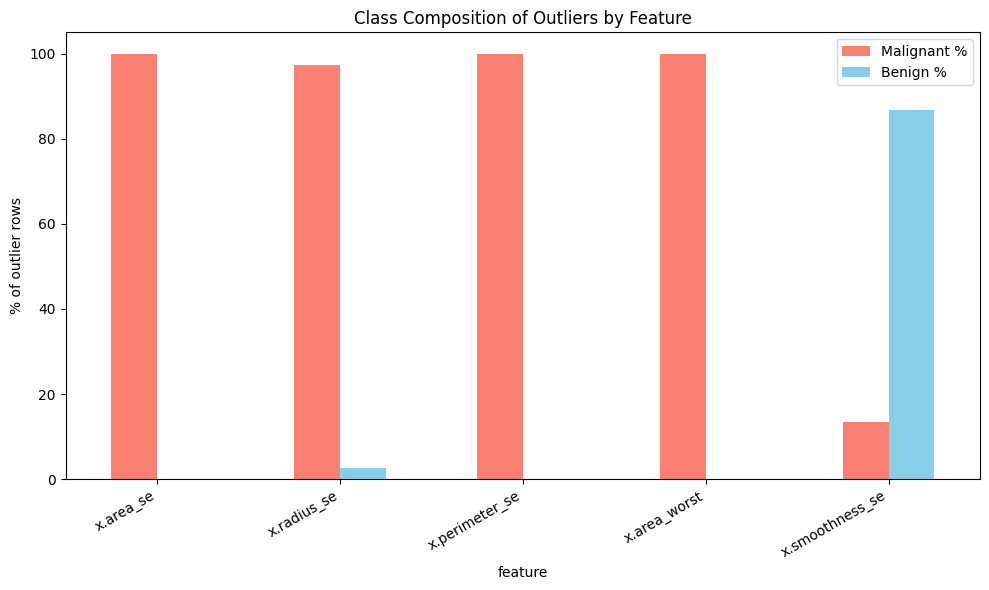

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

top_outlier_features = ['x.area_se', 'x.radius_se', 'x.perimeter_se',
                         'x.area_worst', 'x.smoothness_se']

outlier_by_class = []

for col in top_outlier_features:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    m_pct = (outliers['y'] == 'M').mean() * 100
    b_pct = (outliers['y'] == 'B').mean() * 100
    outlier_by_class.append({'feature': col, 'Malignant %': m_pct, 'Benign %': b_pct})

outlier_df = pd.DataFrame(outlier_by_class).set_index('feature')

ax = outlier_df.plot(kind='bar', figsize=(10, 6), color=['salmon', 'skyblue'])

plt.ylabel('% of outlier rows')
plt.title('Class Composition of Outliers by Feature')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

Outliers in size-related features (area, perimeter, radius) are almost entirely driven by malignant cases (97–100%), confirming they represent real tumor irregularity rather than noise, though this pattern doesn't hold for all features (e.g., smoothness_se skews benign), so outliers were retained overall rather than removed.

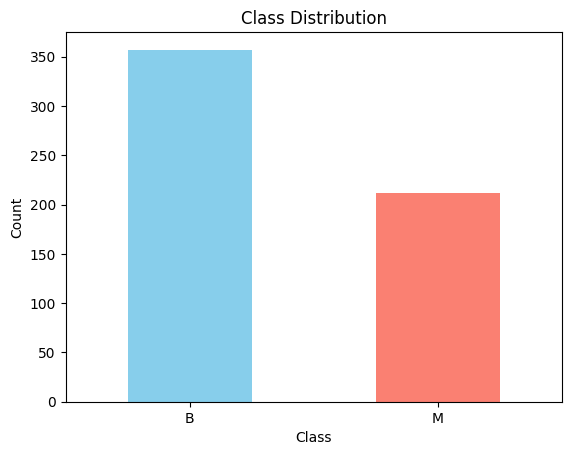

In [53]:
import matplotlib.pyplot as plt

df['y'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

Target Attribute shows class imbalance

In [26]:
df.drop('Unnamed: 0',axis=1,inplace=True)

In [27]:
df.head()

,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,x.radius_se,x.texture_se,x.perimeter_se,x.area_se,x.smoothness_se,x.compactness_se,x.concavity_se,x.concave_pts_se,x.symmetry_se,x.fractal_dim_se,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,0.2699,0.7886,2.058,23.560,0.008462,0.014600,0.02387,0.013150,0.01980,0.002300,15.110,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,0.1852,0.7477,1.383,14.670,0.004097,0.018980,0.01698,0.006490,0.01678,0.002425,14.500,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,0.2773,0.9768,1.909,15.700,0.009606,0.014320,0.01985,0.014210,0.02027,0.002968,10.230,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,0.1839,2.3420,1.170,14.160,0.004352,0.004899,0.01343,0.011640,0.02671,0.001777,13.300,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,0.1563,0.9567,1.094,8.205,0.008968,0.016460,0.01588,0.005917,0.02574,0.002582,8.964,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


### **Split the dataset into training and testing sets**

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (455, 30)
Testing set size: (114, 30)


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

### **Training KNN and Logistic Regression Models**

#### **KNN**

Train Test Split and Feature Scaling

In [59]:
from sklearn.model_selection import train_test_split, cross_val_score

X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (455, 30)
Testing set size: (114, 30)


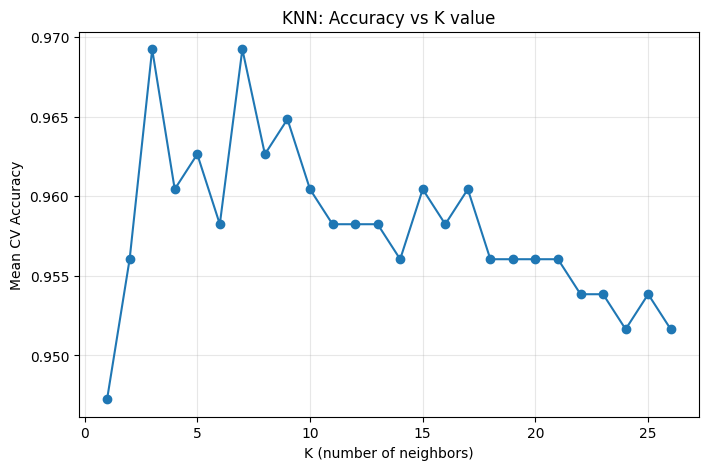

Best K based on cross-validation: 3


In [60]:

k_range = range(1, 27)
cv_scores = []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), cv_scores, marker='o')
plt.xlabel('K (number of neighbors)')
plt.ylabel('Mean CV Accuracy')
plt.title('KNN: Accuracy vs K value')
plt.grid(True, alpha=0.3)
plt.show()

best_k = list(k_range)[np.argmax(cv_scores)]
print(f"Best K based on cross-validation: {best_k}")

In [61]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

In [62]:
log_reg = LogisticRegression(max_iter=5000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

### **Evaluation**

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, auc, precision_recall_curve)


----- K-Nearest Neighbors -----
Accuracy : 0.9386
Precision: 0.9730
Recall   : 0.8571
F1 Score : 0.9114
Confusion Matrix:
 [[36  6]
 [ 1 71]]


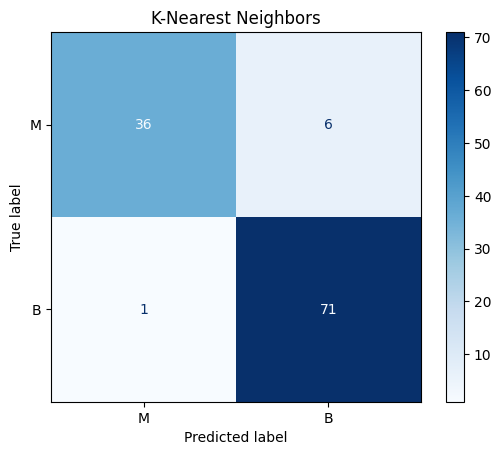


----- Logistic Regression -----
Accuracy : 0.9649
Precision: 0.9750
Recall   : 0.9286
F1 Score : 0.9512
Confusion Matrix:
 [[39  3]
 [ 1 71]]


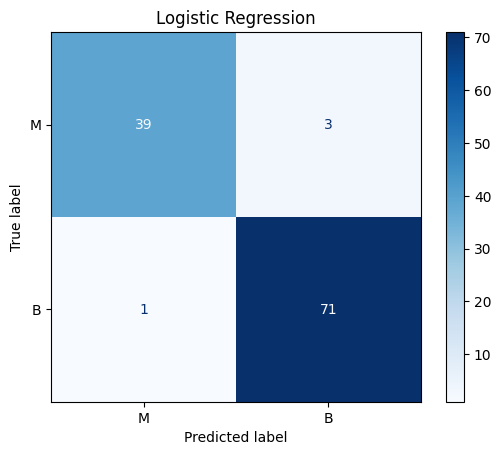

In [66]:
def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label='M')
    rec = recall_score(y_true, y_pred, pos_label='M')
    f1 = f1_score(y_true, y_pred, pos_label='M')
    cm = confusion_matrix(y_true, y_pred, labels=['M', 'B'])

    print(f"\n----- {model_name} -----")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print("Confusion Matrix:\n", cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['M', 'B'])
    disp.plot(cmap='Blues')
    plt.title(model_name)
    plt.show()

    return [model_name, acc, prec, rec, f1]

eval_results = []
eval_results.append(evaluate_model(y_test, y_pred_knn, "K-Nearest Neighbors"))
eval_results.append(evaluate_model(y_test, y_pred_lr, "Logistic Regression"))

Logistic Regression is preferable for this diagnostic task because it minimizes Type II errors (missed malignant cases), which carry far greater clinical risk than the Type I errors (false alarms) both models commit equally.

Recall (sensitivity) is the critical metric here since it is inversely related to the false negative rate — Logistic Regression's higher recall (0.9286) compared to KNN (0.8571) confirms it produces fewer Type II errors, making it more clinically reliable despite both models achieving similar precision.

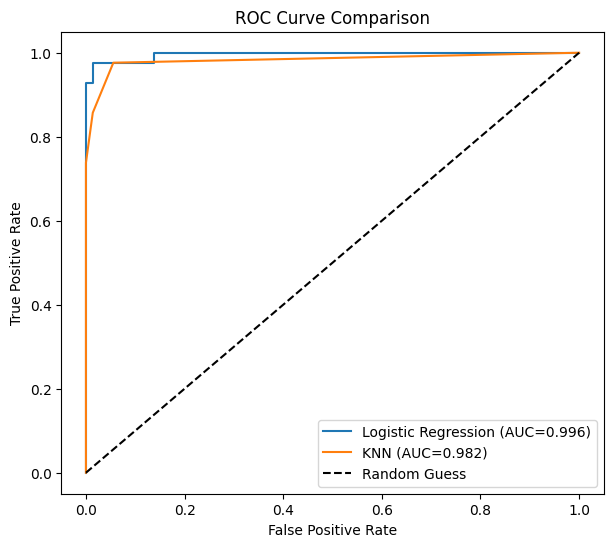

In [67]:
y_test_bin = (y_test == 'M').astype(int)
lr_probs = log_reg.predict_proba(X_test_scaled)[:, list(log_reg.classes_).index('M')]
knn_probs = knn.predict_proba(X_test_scaled)[:, list(knn.classes_).index('M')]

fpr_lr, tpr_lr, _ = roc_curve(y_test_bin, lr_probs)
fpr_knn, tpr_knn, _ = roc_curve(y_test_bin, knn_probs)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc(fpr_lr, tpr_lr):.3f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC={auc(fpr_knn, tpr_knn):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

Logistic Regression's curve hugs the top-left corner more tightly, meaning it separates malignant from benign cases more cleanly than KNN, whose curve dips slightly lower before catching up, likely because KNN's distance-based decisions get a bit noisier near the decision boundary while Logistic Regression's smooth probability estimates handle borderline cases more consistently.


Model Comparison Table:
              Model  Accuracy  Precision   Recall  F1 Score
K-Nearest Neighbors  0.938596   0.972973 0.857143  0.911392
Logistic Regression  0.964912   0.975000 0.928571  0.951220


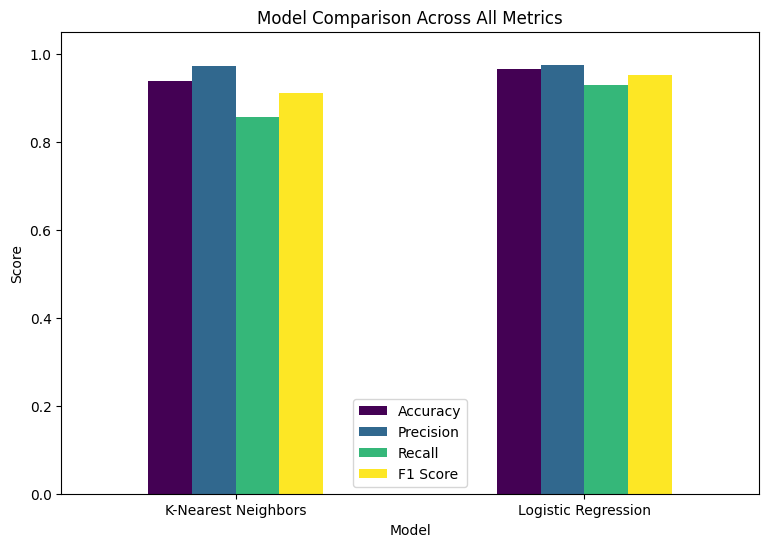

In [68]:
comparison_df = pd.DataFrame(eval_results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
print("\nModel Comparison Table:")
print(comparison_df.to_string(index=False))

comparison_df.set_index('Model').plot(kind='bar', figsize=(9, 6), colormap='viridis')
plt.title('Model Comparison Across All Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.show()

In [70]:
best_model = comparison_df.loc[comparison_df['F1 Score'].idxmax(), 'Model']
print(f"\nBased on F1 Score, the better-performing classifier is: {best_model}")


Based on F1 Score, the better-performing classifier is: Logistic Regression


Better-performing classifier is: Logistic Regression